# 102.4. Retrieve a TAP job by URL

<div style="max-width:300px; float: left; margin-right: 1em">

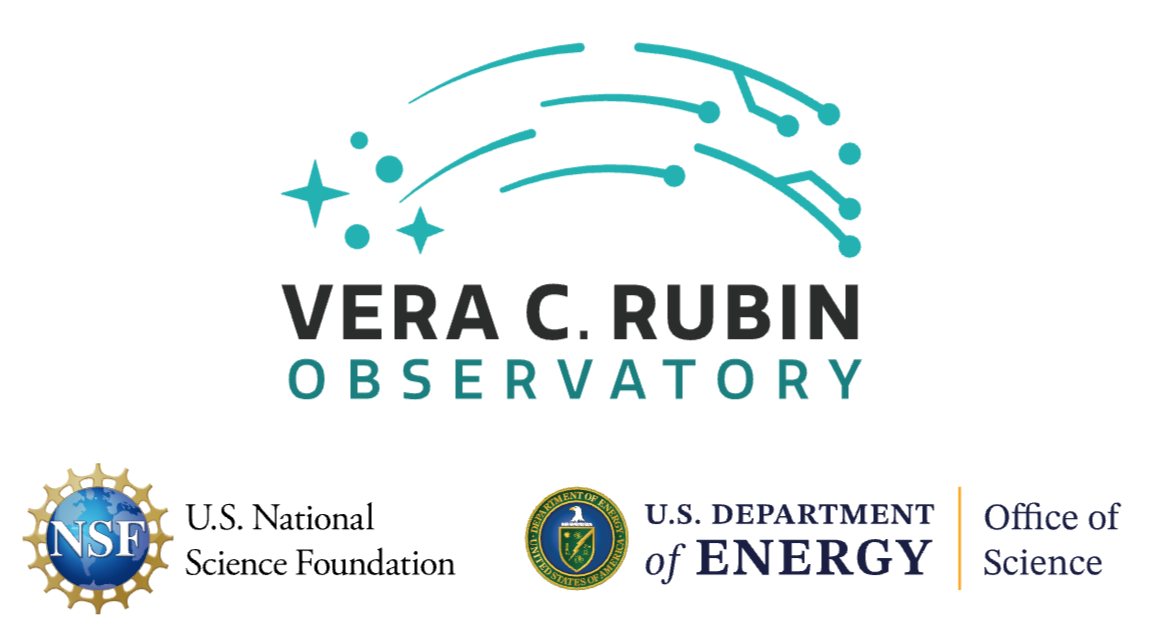

</div>

For the Rubin Science Platform at data.lsst.cloud. <br>
Data Release: <a href="https://dp2.lsst.io">Data Preview 2</a> <br>
Container Size: large <br>
LSST Science Pipelines version: r30.0.8 <br>
Last verified to run: 2026-07-16 <br>
Repository: <a href="https://github.com/lsst/tutorial-notebooks">github.com/lsst/tutorial-notebooks</a> <br>

**Learning objective:** How to use the TAP service's job URLs.

**LSST data products:** `Object` table

**Packages:** `lsst.rsp.RSPDiscovery` and `lsst.rsp.retrieve_query`

**Credit:** Originally developed by the Rubin Community Science team.
Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

TAP provides standardized access to catalog data for discovery, search, and retrieval.
Full [documentation for TAP](http://www.ivoa.net/documents/TAP) is provided by the
International Virtual Observatory Alliance (IVOA).

**Related tutorials**: The other 100-level tutorials in this series demonstrate how to use the TAP service. The 200-level tutorials describe the contents of the catalog data.

### 1.1. Import packages

Import the necessary RSP utilities for establishing a TAP service connection and retrieving query results.

In [6]:
from lsst.rsp import RSPDiscovery, retrieve_query

### 1.2. Define parameters

Instantiate `RSPDiscovery` with the DP2 release, create an instance of the TAP service, and assert that it exists.

In [5]:
discovery = RSPDiscovery("dp2")
service = discovery.get_tap_client()
assert service is not None

## 2. The job URL

Job results are generally available from previously run queries, and can be retrieved by the same account that executed the query if the URL of the job is known and if the job has not been deleted.

The job URL will not work for another user account - to share queries, share the ADQL statements instead.

Do not use `job.delete()` if the results will be retrieved later!

First, define a small, simple cone search query on the `Object` table.

In [7]:
query = """SELECT coord_ra, coord_dec
        FROM dp2.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),
        CIRCLE('ICRS', 53, -28, 0.01)) = 1"""
print(query)

SELECT coord_ra, coord_dec
        FROM dp2.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),
        CIRCLE('ICRS', 53, -28, 0.01)) = 1


Execute the query asynchronously, but do not fetch the results.
Instead, get the job URL as a string and print it.

In [8]:
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'

job_url = str(job.url)
print('job URL: ', job_url)

Job phase is COMPLETED
job URL:  https://data-int.lsst.cloud/api/tap/async/qwmljw03c9vfxch0


### 2.1. Retrieve data from a job URL

This URL can be used to retrieve the query results.

Retrieve the job by passing `job_url` to `retrieve_query`, then retrieve the results with `fetch_result()`.

In [9]:
retrieved_job = retrieve_query(job_url)
retrieved_results = retrieved_job.fetch_result().to_table()

In [10]:
retrieved_results

coord_ra,coord_dec
deg,deg
float64,float64
53.00974122815018,-28.0050175995451
52.992207474582024,-27.99425087611583
52.9965043798098,-27.993613483347524
53.00147739650592,-27.993341345162747
52.99994283136329,-27.994578483538152
52.9997436002789,-27.992986558714172
52.992623866301585,-28.001834993732462
53.00544582690133,-28.000493786161528


Clean up.

In [11]:
job.delete()
del query, job_url, retrieved_job, retrieved_results

## 3. Get a job's URL

### 3.1. Use the Job Monitor

The Portal Aspect of the Rubin Science Platform provides a direct access to the "Job Monitor" tab. Click on the tab to see a list of all recent jobs. Alternatively, when working within the Notebook Aspect, open the "Firefly Viewer" from the "Launcher" and then click on the Job Monitor tab. 

In the Job Monitor, click on the "information" icon in the top row (most recent job) - it is the letter "i" in a circle. The following pop-up will appear, and the job URL is under the "Extra Information". 


<div style="max-width:500px;margin-right: auto; margin-right: 0;">
    
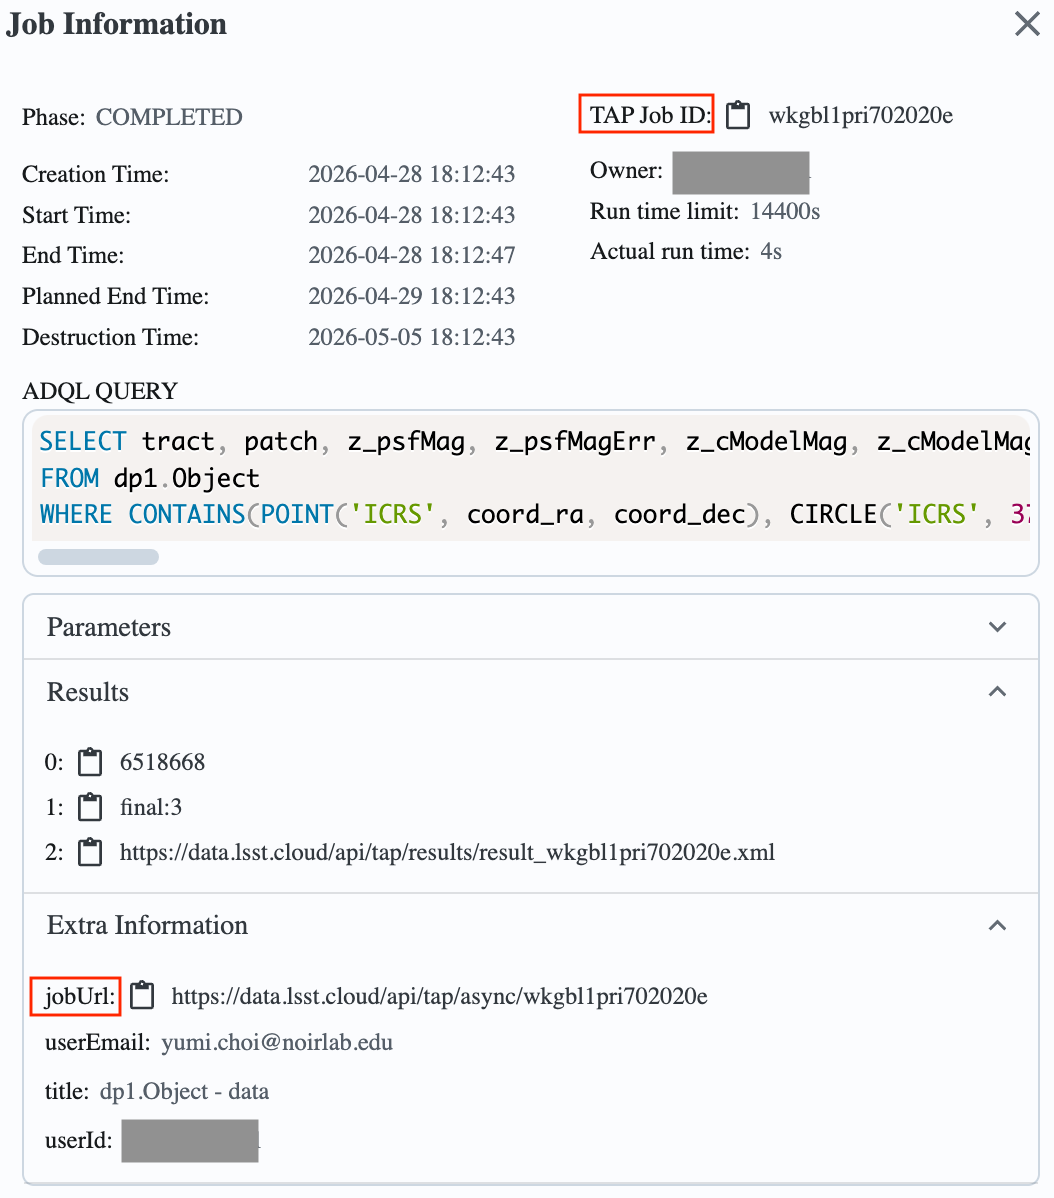

</div>

> **Figure 1:** The pop-up window of job information. This pop-up window will also appear by clicking on the "information" icon above the table in the Portal's Result tab.

#### 3.1.1. Retrieve data from a job URL

Portal-based queries display their job URLs in the Job Monitor's information as seen in Figure 1. Click on the clipboard icon next to `jobUrl` (highlighted in a red box at the bottom of Figure 1) to copy the URL. On the other hand, notebook-based queries only display their job IDs (highlighted in a red box at the top of Figure 1). Job URLs can be manually constructed by appending the job ID to the end of `https://data.lsst.cloud/api/tap/async/`. 

Paste the job URL into the empty string in the cell below to define `job_url`.

Uncomment the lines and execute the cell to retrieve the results.

In [12]:
# job_url = ''
# retrieved_job = retrieve_query(job_url)
# retrieved_results = retrieved_job.fetch_result().to_table()
# print(len(retrieved_results))

### 3.2. Use the Jobs menu

The "Jobs" menu provides several convenient ways to generate pre-populated notebooks to quickly retrieve past query metadata and/or results.

1. "Open from your TAP query history": Provide a query job ID or URL you wish to retrieve. Clicking "Create" opens a new, pre-populated notebook that allows you to retrieve the query results.
   
2. "All TAP queries": Selecting this option opens a pre-populated notebook window designed to retrieve a list of your recent query IDs.
   
3. "Recent Queries": This allows you to select from five most recent queries. Hovering over a query ID displays the associated ADQL query. Once a query ID is selected, a new pre-populated notebook opens for you to retrieve the query results.

<div style="max-width:800px; float: left; margin-right: 1em">

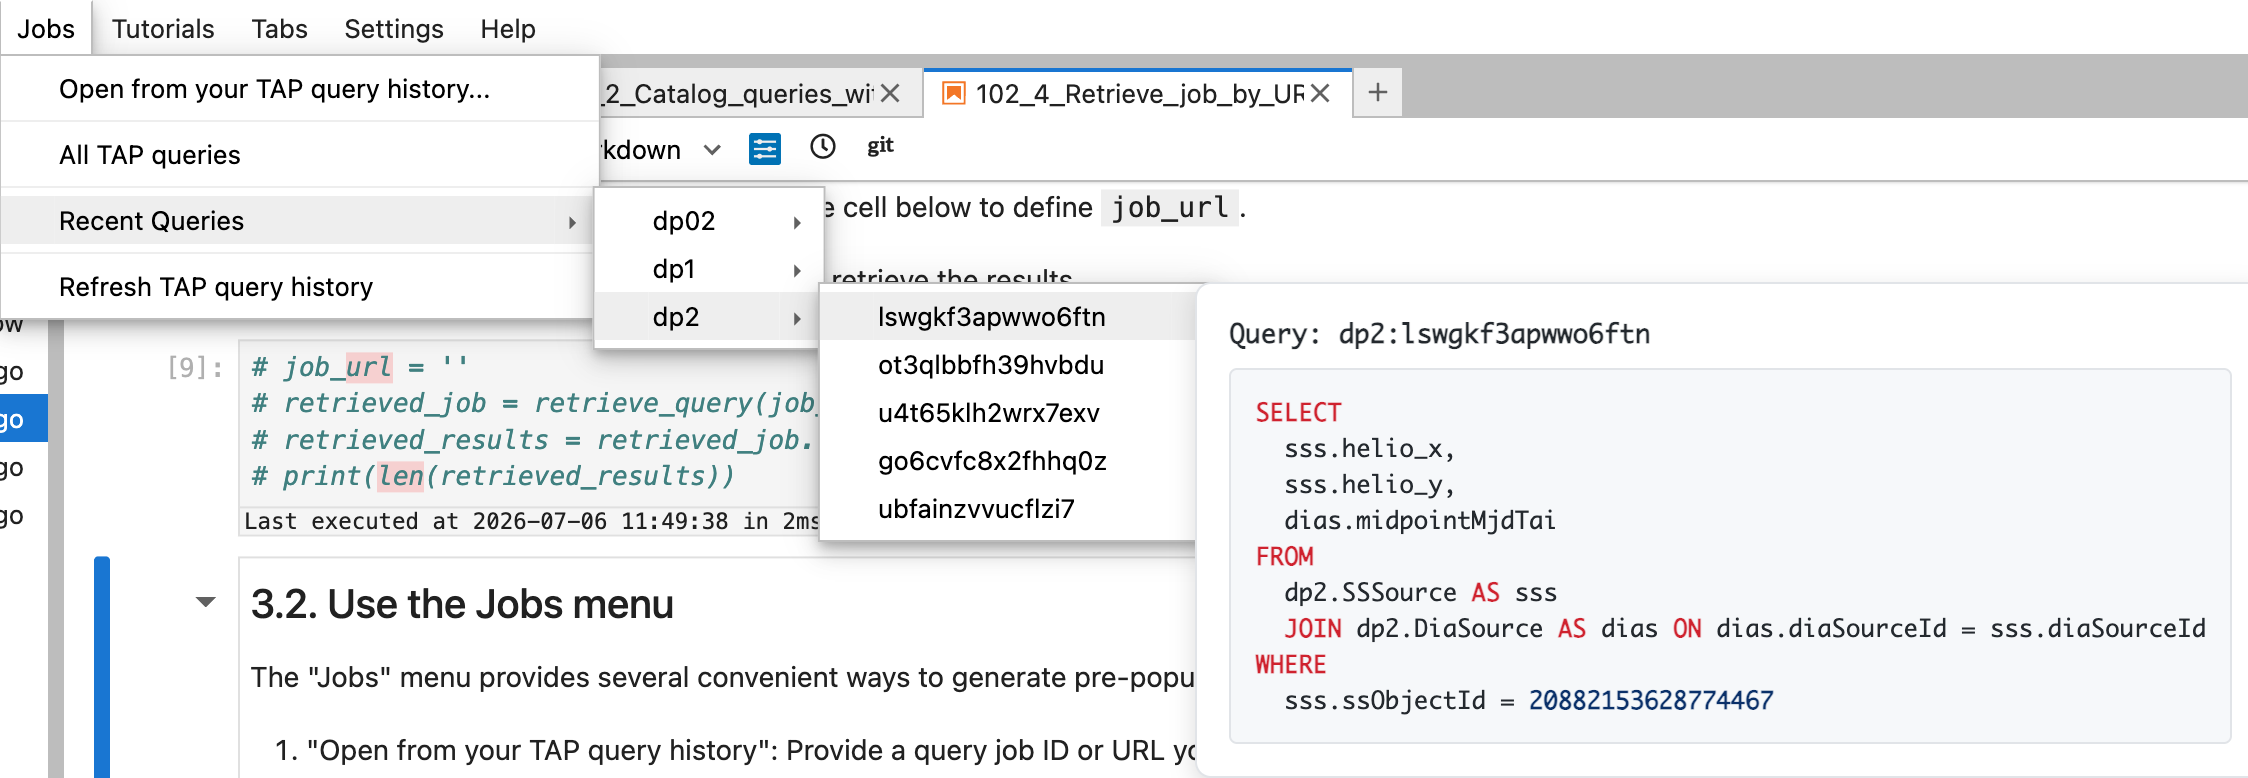

</div>
<div style="clear: both;"></div>

> **Figure 2:** Pop-up window displaying the ADQL query associated with the chosen job ID.
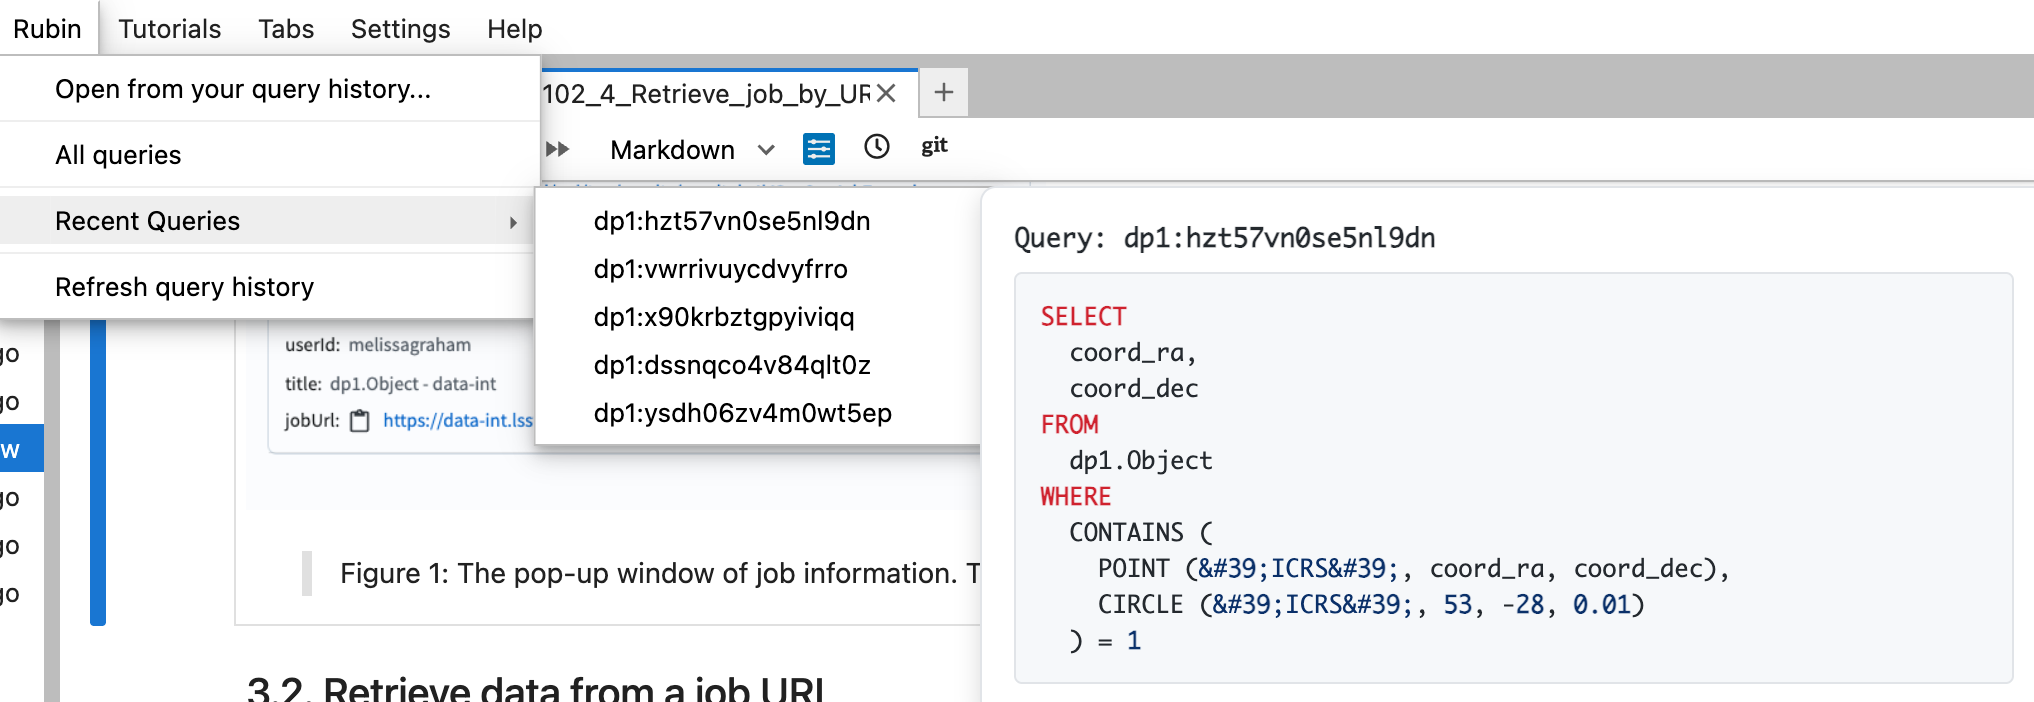
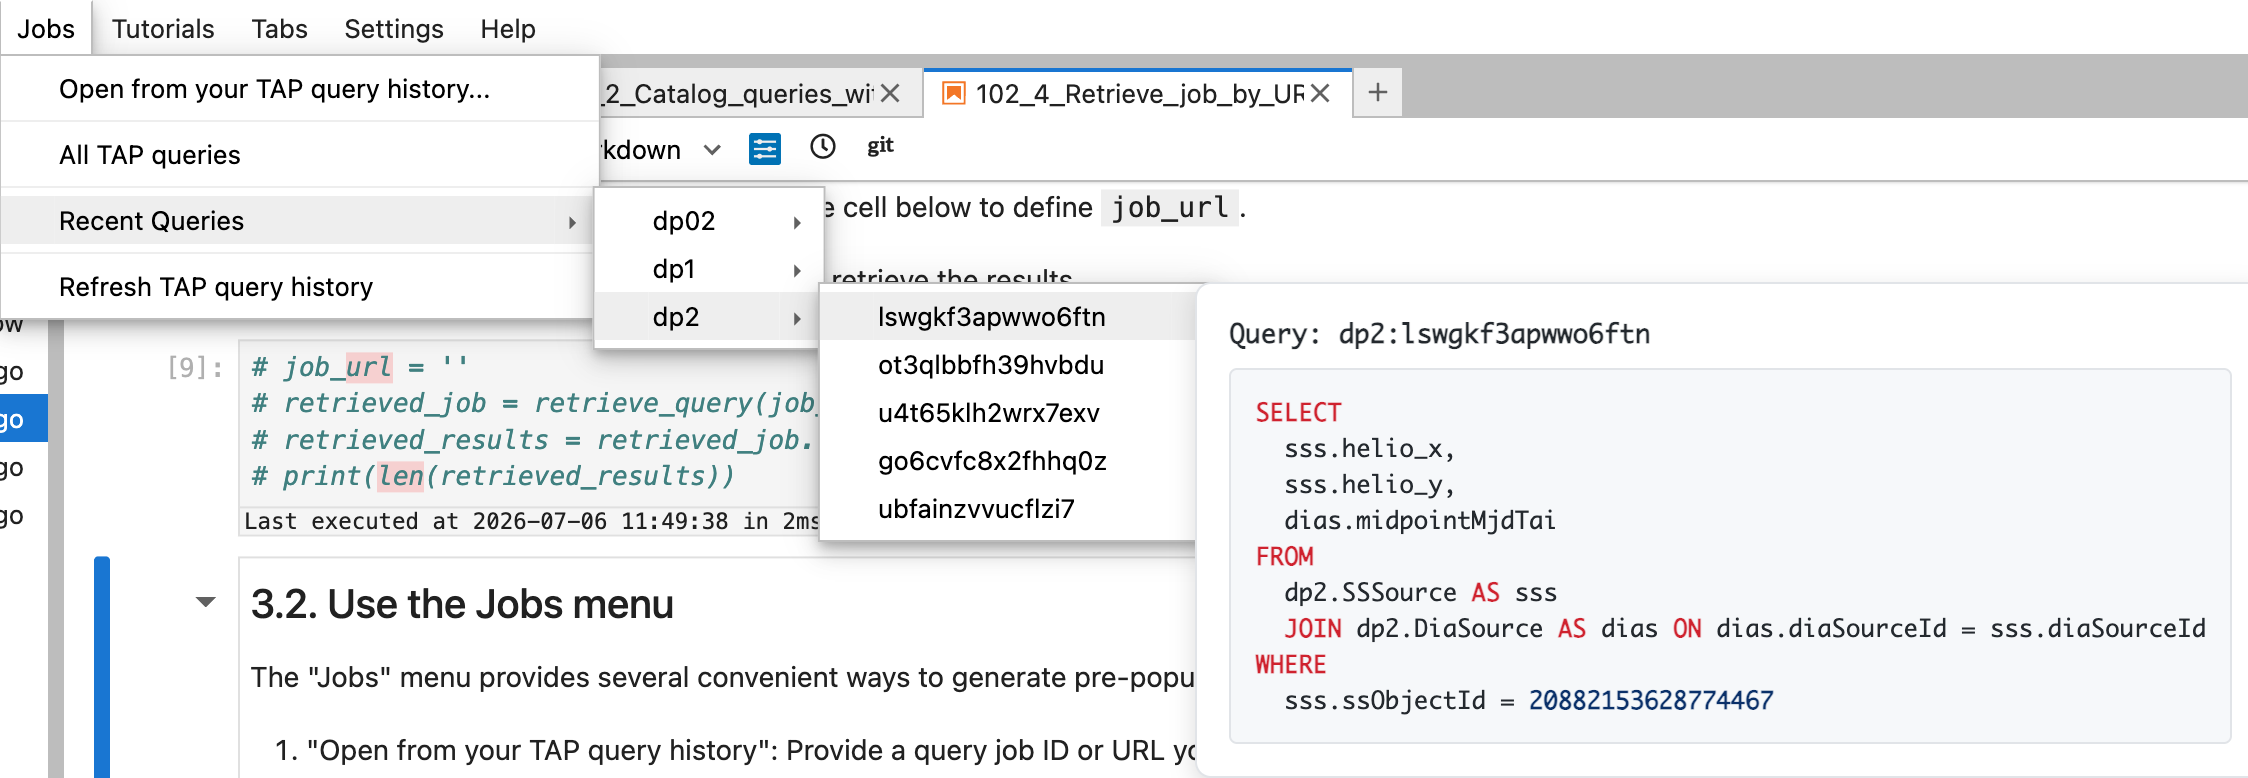